# Online vs Batch learning, practice

Pour ouvrir le notebook, clicker sur le bouton suivant :

<a href="https://colab.research.google.com/drive/16xMwLrRTKexlTC2-07pzv5Cwgav03AuR?usp=sharing"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Ouvrir dans Colab" class="colab-badge" height="32"></a>

⚠️ enregistré une copie dans votre Drive, pour garder votre travail


Workshop: predict the temperature of a greenhouse.

Context. A greenhouse has indoor sensors (temperature, humidity) and an outdoor weather station.
We want a model that predicts the indoor parametres. 

So, in greenhouse conditions change over time (winter → spring, aging sensors, new crops). Should we:
- 🧊 Batch learning: learn once from past data, then freeze the model?
- 🌊 Online learning: keep learning, one measurement at a time?

Our real greenhouse data is private, so we use a similar public dataset:
[UCI Appliances Energy Prediction](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction).
Indoor temperature/humidity sensors + a weather station, one measurement every 10 minutes, January to May 2016, ça suffira pour notre exercice.

> 💡 No data science background needed: run the cells one by one (`Shift + Enter`) and read the comments.

## 0. Install and imports python package

In [27]:
!pip install -q river

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from river import linear_model, preprocessing, optim

# One color per strategy, used in every chart
COLORS = {"actual": "#444444", "batch": "#e065f0", 
          "online": "#4b1e97", "batch retrained": "#b659ea"}
plt.rcParams.update({"figure.figsize": (12, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "lines.linewidth": 2})


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Load data

We download the CSV file directly from the UCI website.

In [17]:
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv"
raw = pd.read_csv(URL, parse_dates=["date"])
print(f"{len(raw)} measurements, from {raw.date.min()} to {raw.date.max()}")
raw.head()

19735 measurements, from 2016-01-11 17:00:00 to 2016-05-27 18:00:00


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


There are many columns. We keep only what looks like a greenhouse:

| Column | Meaning | Role |
|---|---|---|
| `T_out` | outdoor temperature (°C) | feature |
| `RH_out` | outdoor humidity (%) | feature |
| `Windspeed` | wind speed (m/s) | feature |
| `h_sin`, `h_cos` | time of day | feature |
| `T_in` | indoor temperature (average of the indoor sensors) | target |

💡 Why `sin`/`cos` for the hour? <br>
So the model knows that 11 pm and midnight are close, time is cyclic

In [18]:
df = pd.DataFrame({"date": raw["date"]})
df["T_out"] = raw["T_out"]
df["RH_out"] = raw["RH_out"]
df["Windspeed"] = raw["Windspeed"]
hour = raw["date"].dt.hour
df["h_sin"] = np.sin(2 * np.pi * hour / 24)
df["h_cos"] = np.cos(2 * np.pi * hour / 24)
# Indoor temperature = average of the 8 indoor sensors (T6 is outside, so we skip it)
df["T_in"] = raw[["T1", "T2", "T3", "T4", "T5", "T7", "T8", "T9"]].mean(axis=1)

INPUTS = ["T_out", "RH_out", "Windspeed", "h_sin", "h_cos"]
TARGET = "T_in"
df.head()

,date,T_out,RH_out,Windspeed,h_sin,h_cos,T_in
0,2016-01-11 17:00:00,6.600000,92.0,7.000000,-0.965926,-0.258819,18.435000
1,2016-01-11 17:10:00,6.483333,92.0,6.666667,-0.965926,-0.258819,18.439167
2,2016-01-11 17:20:00,6.366667,92.0,6.333333,-0.965926,-0.258819,18.421667
3,2016-01-11 17:30:00,6.250000,92.0,6.000000,-0.965926,-0.258819,18.396250
4,2016-01-11 17:40:00,6.133333,92.0,5.666667,-0.965926,-0.258819,18.408750


## 2. Look at the data first

Always start with a chart. Here is the daily average temperature.

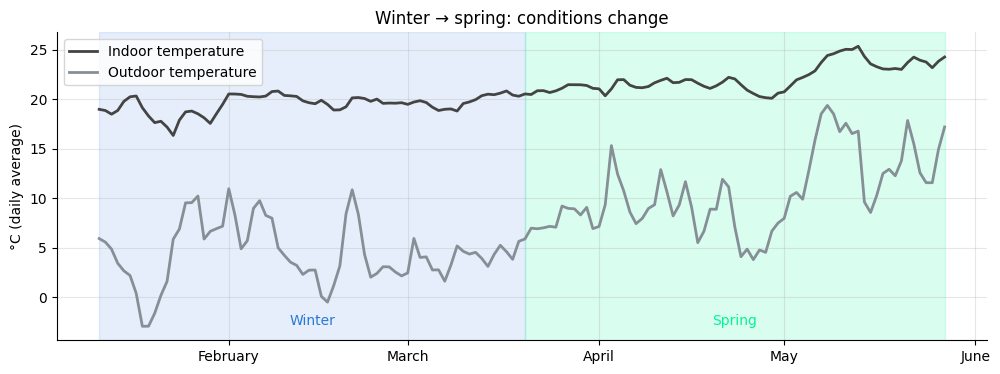

In [ ]:
import matplotlib.dates as mdates

MONTH_NAMES = ["January", "February", "March", "April", "May", "June",
               "July"]

daily = df.set_index("date")[["T_out", "T_in"]].resample("D").mean()
start, spring_start, end = daily.index.min(), pd.Timestamp("2016-03-20"), daily.index.max()   # spring equinox

fig, ax = plt.subplots()
ax.axvspan(start, spring_start, color="#2a78d6", alpha=0.12)
ax.axvspan(spring_start, end, color="#04f494", alpha=0.15)
bottom = ax.get_xaxis_transform()   # x = dates, y = 0 (bottom) to 1 (top) of the chart
ax.text(start + (spring_start - start) / 2, 0.04, "Winter", transform=bottom,
        ha="center", va="bottom", color="#2a78d6")
ax.text(spring_start + (end - spring_start) / 2, 0.04, "Spring", transform=bottom,
        ha="center", va="bottom", color="#04f494")

ax.plot(daily.index, daily["T_in"], color="#444444", label="Indoor temperature")
ax.plot(daily.index, daily["T_out"], color="#868e96", label="Outdoor temperature")

# One tick per month, English month names
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: MONTH_NAMES[mdates.num2date(x).month - 1]))

ax.set_ylabel("°C (daily average)")
ax.set_title("Winter → spring: conditions change")
ax.legend(loc="upper left")
plt.show()


If a model learns only from January data, will it still be good in May?

This is drift: today's data no longer looks like the training data.

## 3. 🧊 Batch learning: learn once, then freeze

The classic approach:
1. take the data available at the start (here the first 3 weeks, until February 1st),
2. train a model (a linear regression: a weighted sum of the inputs),
3. use it without ever updating it.

Feature = history

In [ ]:
TRAIN_END = "2016-02-01"
history = df[df.date < TRAIN_END]

batch_model = LinearRegression()
batch_model.fit(history[INPUTS], history[TARGET])      # ← all the learning happens HERE, once

df["pred_batch"] = batch_model.predict(df[INPUTS])     # then we predict the whole period
print(f"Trained on {len(history)} measurements.")
print("Learned weights:", {i: round(float(c), 2) for i, c in zip(INPUTS, batch_model.coef_)})

Trained on 7098 measurements.
Learned weights: {'T_out': 0.05, 'RH_out': -0.01, 'Windspeed': -0.01, 'h_sin': -0.21, 'h_cos': 0.34}


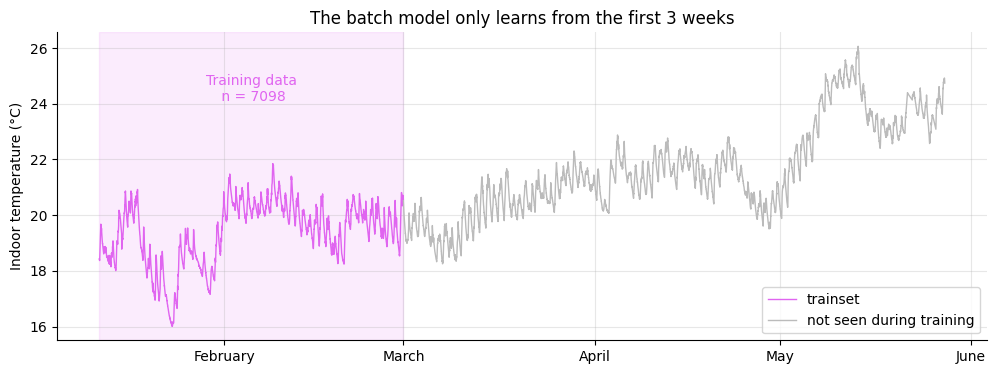

In [ ]:
import matplotlib.dates as mdates

MONTH_NAMES = ["January", "February", "March", "April", "May", "June"]

train_end = pd.Timestamp(TRAIN_END)
train = df[df.date < train_end]
unseen = df[df.date >= train_end]

fig, ax = plt.subplots()
ax.axvspan(df.date.min(), train_end, color=COLORS["batch"], alpha=0.12)
ax.plot(train.date, train[TARGET], color=COLORS["batch"], linewidth=1, label="trainset")
ax.plot(unseen.date, unseen[TARGET], color="#bbbbbb", linewidth=1, label="not seen during training")

bottom = ax.get_xaxis_transform()   # x = dates, y = 0 (bottom) to 1 (top) of the chart
ax.text(df.date.min() + (train_end - df.date.min()) / 2, 24, f"Training data\n n = {len(train)}",
        ha="center", va="bottom", color=COLORS["batch"])

# One tick per month, English month names
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: MONTH_NAMES[mdates.num2date(x).month - 1]))
ax.set_ylabel("Indoor temperature (°C)")
ax.set_title("The batch model trainset")
ax.legend(loc="lower right")
plt.show()


Métrique de performance = mean absolute error (MAE) <br>
on average, how many °C is the model off

In [64]:
MONTHS = ["January", "February", "March", "April", "May"]

def error_by_month(pred_column):
    err = (df[pred_column] - df[TARGET]).abs()
    return err.groupby(df.date.dt.month_name()).mean().reindex(MONTHS).round(2)

error_by_month("pred_batch").to_frame("Batch error (°C)")

,Batch error (°C)
date,
January,1.14
February,0.67
March,0.92
April,1.64
May,3.47


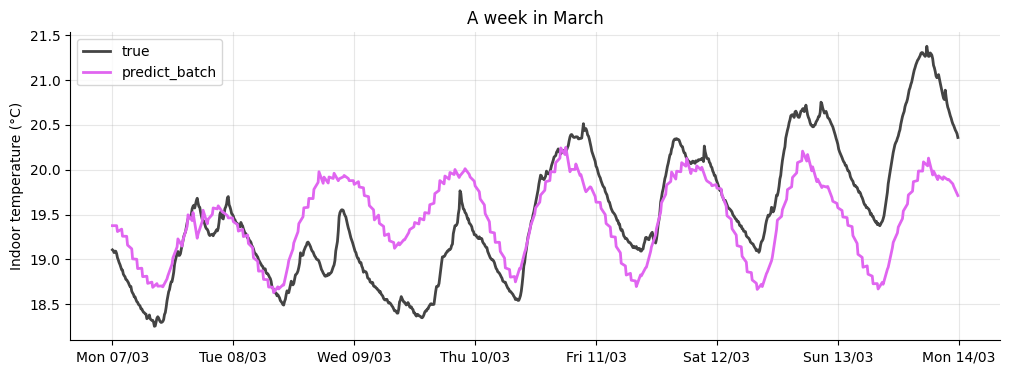

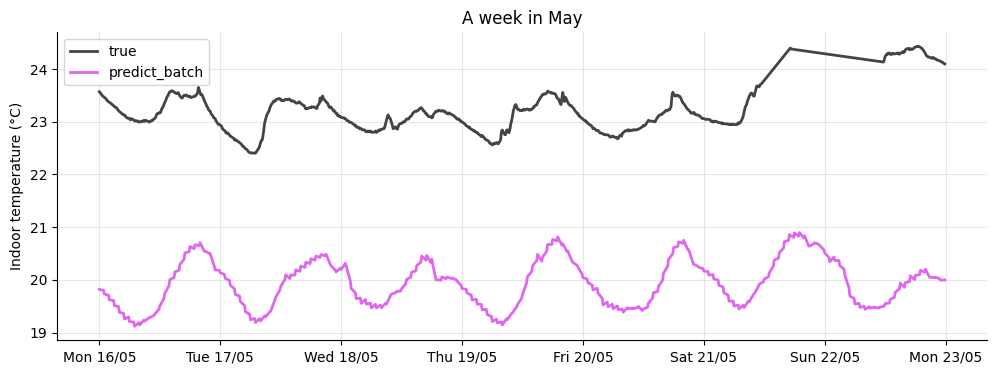

In [ ]:
import matplotlib.dates as mdates

DAY_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

def day_label(x, _):
    d = mdates.num2date(x)
    return f"{DAY_NAMES[d.weekday()]} {d.day:02d}/{d.month:02d}"

def plot_week(start, columns, title):
    s = df[(df.date >= start) & (df.date < pd.Timestamp(start) + pd.Timedelta(days=7))]
    fig, ax = plt.subplots()
    ax.plot(s.date, s[TARGET], color=COLORS["actual"], label="true")
    for name, col in columns.items():
        ax.plot(s.date, s[col], color=COLORS[name], label=f"predict_{name}")
    # One tick per day: English day name + day/month
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(plt.FuncFormatter(day_label))
    ax.set_ylabel("Indoor temperature (°C)")
    ax.set_title(title)
    ax.legend(loc="best")
    plt.show()


plot_week("2016-03-07", {"batch": "pred_batch"}, "A week in March, predict vs true values")
plot_week("2016-05-16", {"batch": "pred_batch"}, "A week in May, predict vs true values")

## 4. 🌊 Online learning: learn from every new data

We use the [`river`](https://riverml.xyz) library, built for learning from data streams.

Two lines, repeated for each new data, in time order:
```python
prediction = model.predict_one(x)   # 1. predict BEFORE knowing the true value
model.learn_one(x, y)               # 2. the true value arrives → adjust the model a little
```
This is called prequential evaluation (??) (predict, then learn): the model never sees the answer before predicting, so the comparison is fair.

In [70]:
def online_learning(data, learning_rate=0.01):
    model = preprocessing.StandardScaler() | linear_model.LinearRegression(
        optimizer=optim.SGD(learning_rate))
    predictions, T_out_weights = [], []
    for x, y in zip(data[INPUTS].to_dict("records"), data[TARGET]):
        predictions.append(model.predict_one(x))   # 1. predict
        model.learn_one(x, y)                      # 2. learn
        T_out_weights.append(model["LinearRegression"].weights.get("T_out", 0))
    return np.array(predictions), np.array(T_out_weights)

df["pred_online"], T_out_weights = online_learning(df)
pd.DataFrame({"Batch error (°C)": error_by_month("pred_batch"),
              "Online error (°C)": error_by_month("pred_online")})

,Batch error (°C),Online error (°C)
date,,
January,1.14,0.93
February,0.67,0.16
March,0.92,0.14
April,1.64,0.14
May,3.47,0.18


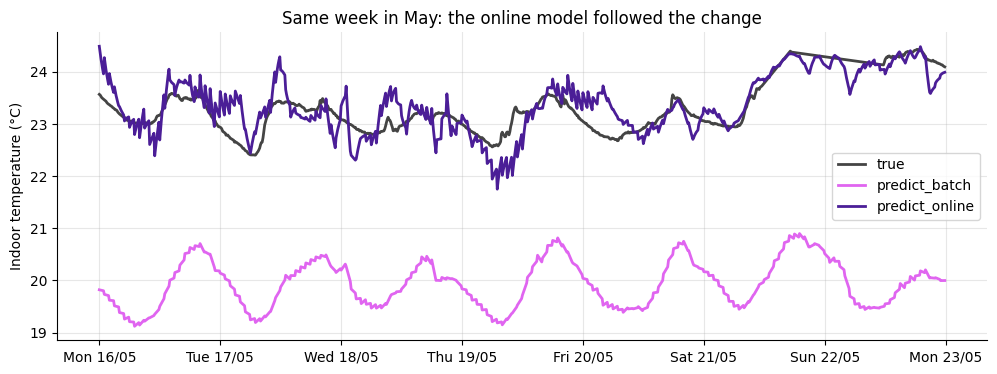

In [75]:
plot_week("2016-05-16", {"batch": "pred_batch", "online": "pred_online"},
          "Same week in May: the online model followed the change")

The online model changes over time. You can see it in the weight it gives to the outdoor temperature:

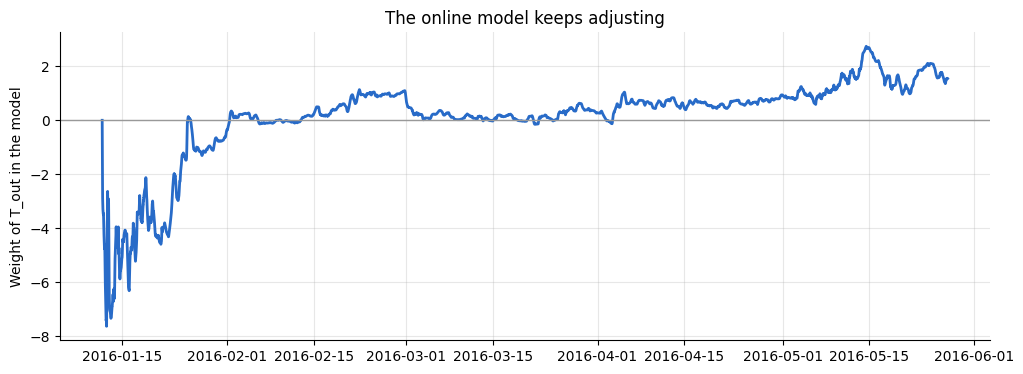

In [ ]:
fig, ax = plt.subplots()
ax.plot(df.date, T_out_weights, color=COLORS["online"])
ax.axhline(0, color="#999999", linewidth=1)
ax.set_ylabel("Weight of T_out in the model")
ax.set_title("Online model: T_out feature importance over time")
plt.show()

## 5. Middle ground: retrain the batch model regularly

Many teams retrain their batch model on a schedule (every week, every month…) using all past data.
Let's compare the three strategies.

In [76]:
df["pred_batch_weekly"] = np.nan
weeks = df.date.dt.to_period("W")
for week in weeks.unique()[3:]:                        # wait for 3 weeks of history
    past = df.date < week.start_time
    m = LinearRegression().fit(df.loc[past, INPUTS], df.loc[past, TARGET])
    current = (weeks == week).values
    df.loc[current, "pred_batch_weekly"] = m.predict(df.loc[current, INPUTS])

pd.DataFrame({"batch (frozen)": error_by_month("pred_batch"),
              "batch retrained weekly": error_by_month("pred_batch_weekly"),
              "online": error_by_month("pred_online")})

,batch (frozen),batch retrained weekly,online
date,,,
January,1.14,NaN,0.93
February,0.67,1.07,0.16
March,0.92,0.83,0.14
April,1.64,0.89,0.14
May,3.47,1.33,0.18


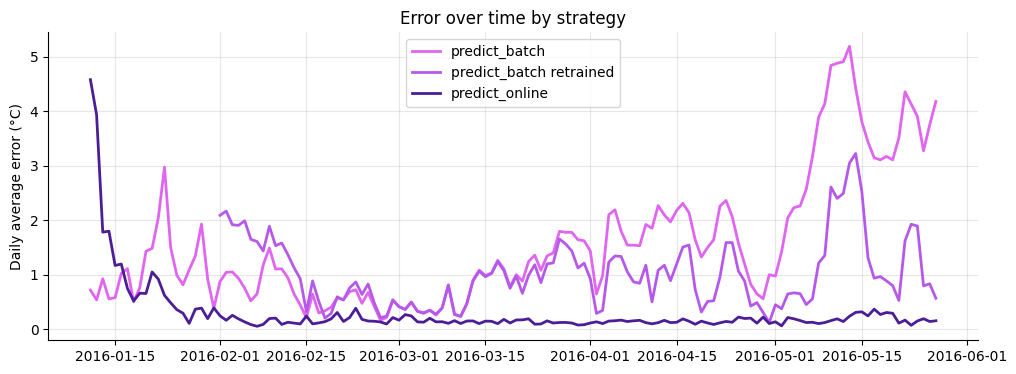

In [79]:
errors = pd.DataFrame({
    "batch": (df.pred_batch - df[TARGET]).abs(),
    "batch retrained": (df.pred_batch_weekly - df[TARGET]).abs(),
    "online": (df.pred_online - df[TARGET]).abs(),
}).set_index(df.date).resample("D").mean()

fig, ax = plt.subplots()
for name in errors.columns:
    ax.plot(errors.index, errors[name], color=COLORS[name], label=f"predict_{name}")
ax.set_ylabel("Daily average error (°C)")
ax.set_title("Error over time by strategy")
ax.legend(loc="best")
plt.show()

## 6. ⚠️ Online learning pitfalls

The limits

### Pitfall 1: a sensor fails
Let's simulate a faulty indoor sensor that reads 10 °C too high for 3 days (March 10 to 13).
The online model will learn this error… and then have to unlearn it.

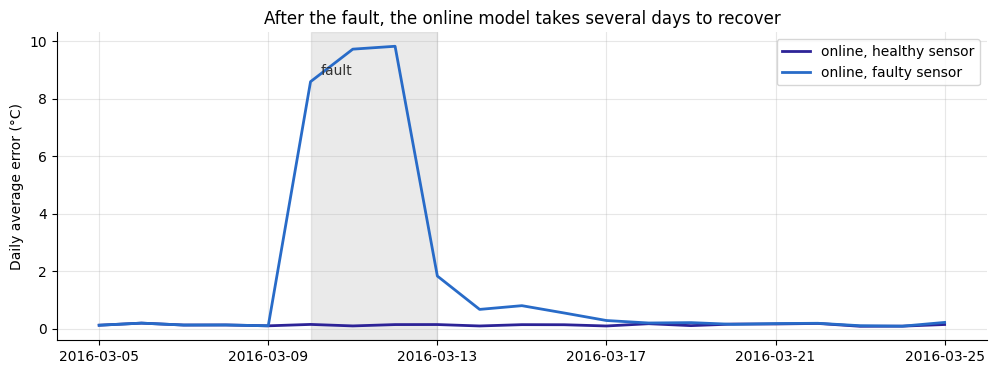

In [13]:
faulty = df.copy()
fault_period = (faulty.date >= "2016-03-10") & (faulty.date < "2016-03-13")
faulty.loc[fault_period, TARGET] += 10                 # the sensor is wrong

pred_faulty, _ = online_learning(faulty)
# compare with the TRUE temperature (from the healthy sensor)
err_faulty = pd.Series(np.abs(pred_faulty - df[TARGET].values), index=df.date).resample("D").mean()

zoom = slice("2016-03-05", "2016-03-25")
fig, ax = plt.subplots()
ax.plot(errors["online"][zoom], color=COLORS["batch"], label="online, healthy sensor")
ax.plot(err_faulty[zoom], color=COLORS["online"], label="online, faulty sensor")
ax.axvspan(pd.Timestamp("2016-03-10"), pd.Timestamp("2016-03-13"), color="#999999", alpha=0.2)
ax.text(pd.Timestamp("2016-03-10 06:00"), err_faulty[zoom].max() * 0.9, "fault", color="#333333")
ax.set_ylabel("Daily average error (°C)")
ax.set_title("After the fault, the online model takes several days to recover")
ax.legend(loc="upper right")
plt.show()

The frozen batch model would not be affected (it does not learn during the fault).
With online learning, you must check incoming data quality (outliers, stuck sensors…) before feeding it to the model.

### Pitfall 2: learning too fast
The learning rate sets the size of each correction. <br>
Too small: stable, but the model reacts slowly. <br>
Too large: follows the moving minimum quickly, but also reacts to noise and sensor failures. <br>

In [14]:
for rate in [0.001, 0.01, 0.05]:
    pred, _ = online_learning(df, learning_rate=rate)
    mae = np.mean(np.abs(pred - df[TARGET]))
    print(f"learning rate = {rate:<6} → mean error = {mae:,.2f} °C")

learning rate = 0.001  → mean error = 0.27 °C
learning rate = 0.01   → mean error = 0.27 °C
learning rate = 0.05   → mean error = 4,541,377,237.70 °C


👉 With `0.05` the model blows up. Like a gain set too high in a control loop.

## 7. 🧪 Your turn

1. More history for batch: set `TRAIN_END` to `"2016-03-15"` and rerun the cells. Does batch do better in May?
2. Tuning: try other learning rates (`0.002`, `0.02`, `0.03`). Where is the limit?
3. Another sensor: predict a room's humidity instead, e.g. `df["T_in"] = raw["RH_1"]` in the data preparation cell. Do the conclusions hold?
4. Another fault: simulate a stuck sensor (`faulty.loc[fault_period, TARGET] = 20`) instead of an offset.

In [ ]:
# 👉 your turn

## 8. 🏠 Takeaways

| | 🧊 Batch | 🔁 Retrained batch | 🌊 Online |
|---|---|---|---|
| Learning | once, on past data | on a schedule, on past data | at every measurement |
| Training set to start | needed | needed | not needed, learns from the flow |
| With drift | gets worse | follows, with a delay | adapts quickly |
| Memory / compute | all history, once | all history, each time | one measurement at a time, very light |
| Bad data | little impact (if cleaned) | little impact | learns it → monitoring required |
| Reproducibility / audit | easy | easy (versions) | harder (the model keeps changing) |
| Typical use | stable process, certified model | most industrial cases | continuous streams, frequent drift, embedded |